# 17b — ADR Strategy Analysis: City vs Resort

Cùng trình tự phân tích ADR như notebook **17**, nhưng **tách và so sánh** hai phân khúc:

| Segment | Đặc trưng kỳ vọng |
|---------|-------------------|
| **City Hotel** | Công vụ / midweek, seasonality đô thị |
| **Resort Hotel** | Nghỉ dưỡng / weekend & peak hè mạnh hơn |

1. **Seasonality** — monthly trend, weekend vs weekday (theo hotel)
2. **Lead-time vs ADR** — booking window (theo hotel)
3. **Room type premium** — ladder & upsell (theo hotel)
4. **So sánh chéo** — overlay / gap / KPI / slope / cancel-adjusted / small multiples

**Phạm vi chính:** booking không hủy (`is_canceled = 0`), `adr > 0`.  
**Mở rộng (mục Cancel-adjusted):** mọi booking `adr > 0` (kể cả hủy) để so sánh ADR stay vs canceled.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

NOTEBOOK_DIR = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "data").is_dir() else NOTEBOOK_DIR
DATA_PATH = ROOT / "data" / "hotel_bookings_v5.csv"
FIG_DIR = ROOT / "reports" / "figures" / "17b"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MONTH_ORDER = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
DAY_ORDER = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday",
]
WEEKEND_DAYS = {"Friday", "Saturday", "Sunday"}
LEAD_BINS = [-1, 7, 30, 90, 180, 10_000]
LEAD_LABELS = ["0-7", "8-30", "31-90", "91-180", "180+"]
HOTELS = ["City Hotel", "Resort Hotel"]
HOTEL_COLORS = {"City Hotel": "#4C72B0", "Resort Hotel": "#55A868"}

print(f"ROOT: {ROOT}")
print(f"DATA: {DATA_PATH}")
print(f"FIG_DIR: {FIG_DIR}")

ROOT: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python
DATA: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
FIG_DIR: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\reports\figures\17b


In [2]:
def fmt_int(n) -> str:
    return f"{int(round(n)):,}".replace(",", ".")


def fmt_eur(x: float, d: int = 2) -> str:
    return f"{x:,.{d}f} €".replace(",", "X").replace(".", ",").replace("X", ".")


def fmt_pct(x: float, d: int = 1) -> str:
    return f"{x * 100:.{d}f}%".replace(".", ",")


def savefig(name: str) -> Path:
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=140, bbox_inches="tight")
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def enrich(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["arrival_date_month"] = pd.Categorical(
        out["arrival_date_month"], categories=MONTH_ORDER, ordered=True
    )
    out["day_of_week"] = pd.Categorical(
        out["day_of_week"], categories=DAY_ORDER, ordered=True
    )
    out["is_weekend"] = out["day_of_week"].isin(WEEKEND_DAYS)
    out["total_nights"] = (
        out["stays_in_weekend_nights"] + out["stays_in_week_nights"]
    ).clip(lower=0)
    out["booking_revenue"] = out["adr"] * out["total_nights"]
    out["lead_bin"] = pd.cut(
        out["lead_time"],
        bins=LEAD_BINS,
        labels=LEAD_LABELS,
    )
    out["room_match"] = out["reserved_room_type"] == out["assigned_room_type"]
    out["hotel"] = pd.Categorical(out["hotel"], categories=HOTELS, ordered=True)
    out["status_label"] = out["is_canceled"].map({0: "Stay", 1: "Canceled"})
    return out


def load_bookings() -> tuple[pd.DataFrame, pd.DataFrame]:
    # stay = khong huy; bookings = moi adr > 0 (cancel-adjusted)
    df = pd.read_csv(DATA_PATH)
    bookings = enrich(df[df["adr"] > 0])
    stay = bookings[bookings["is_canceled"] == 0].copy()
    return stay, bookings


def subset(hotel: str) -> pd.DataFrame:
    return stay[stay["hotel"] == hotel].copy()


stay, bookings = load_bookings()
city = subset("City Hotel")
resort = subset("Resort Hotel")

print(f"Stay (không hủy): {fmt_int(len(stay))} | Bookings adr>0 (có hủy): {fmt_int(len(bookings))}")
for h, g in [("City Hotel", city), ("Resort Hotel", resort)]:
    print(
        f"  {h}: n={fmt_int(len(g))} | mean ADR={fmt_eur(g['adr'].mean())} | "
        f"median={fmt_eur(g['adr'].median())} | weekend={fmt_pct(g['is_weekend'].mean())}"
    )

overview = (
    stay.groupby("hotel", observed=True)["adr"]
    .agg(bookings="count", mean_adr="mean", median_adr="median", std_adr="std",
         p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75))
)
overview["weekend_share"] = stay.groupby("hotel", observed=True)["is_weekend"].mean()
display(overview.round(2))

Stay (không hủy): 58.066 | Bookings adr>0 (có hủy): 81.178
  City Hotel: n=34.274 | mean ADR=112,05 € | median=105,00 € | weekend=42,5%
  Resort Hotel: n=23.792 | mean ADR=97,09 € | median=77,50 € | weekend=43,5%


,bookings,mean_adr,median_adr,std_adr,p25,p75,weekend_share
hotel,,,,,,,
City Hotel,34274,112.05,105.0,39.61,84.45,133.2,0.42
Resort Hotel,23792,97.09,77.5,60.37,51.80,129.0,0.43


## 0. Snapshot so sánh phân khúc

Baseline trước khi đi vào từng chiều phân tích — phân bố ADR và KPI tổng.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26260\67480814.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26260\67480814.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


Saved: reports\figures\17b\00_segment_adr_snapshot.png


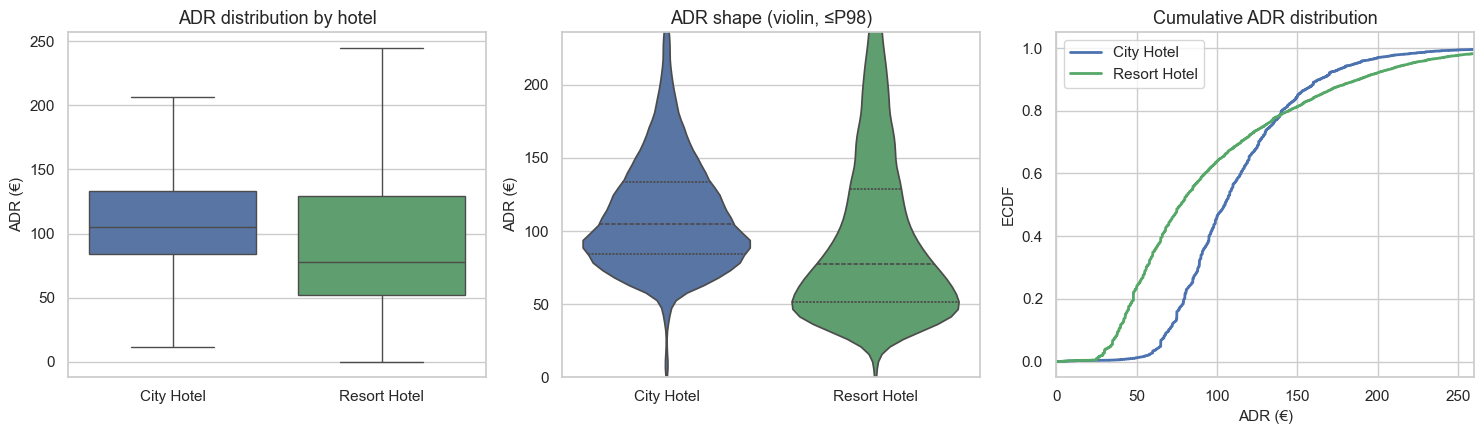

City − Resort (mean): 14,96 € | (median): 27,50 €
Mann–Whitney U p-value: 0.00e+00


In [3]:
# 0.1 Distribution + KPI snapshot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
sns.boxplot(
    data=stay, x="hotel", y="adr", order=HOTELS, showfliers=False,
    palette=HOTEL_COLORS, ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("ADR (€)")
ax.set_title("ADR distribution by hotel")

ax = axes[1]
sns.violinplot(
    data=stay, x="hotel", y="adr", order=HOTELS, cut=0,
    palette=HOTEL_COLORS, ax=ax, inner="quartile",
)
ax.set_ylim(0, stay["adr"].quantile(0.98))
ax.set_xlabel("")
ax.set_ylabel("ADR (€)")
ax.set_title("ADR shape (violin, ≤P98)")

ax = axes[2]
# ECDF overlay
for h in HOTELS:
    s = np.sort(stay.loc[stay["hotel"] == h, "adr"].values)
    y = np.arange(1, len(s) + 1) / len(s)
    ax.plot(s, y, color=HOTEL_COLORS[h], lw=2, label=h)
ax.set_xlim(0, stay["adr"].quantile(0.99))
ax.set_xlabel("ADR (€)")
ax.set_ylabel("ECDF")
ax.set_title("Cumulative ADR distribution")
ax.legend()

savefig("00_segment_adr_snapshot.png")
plt.show()

# Mann–Whitney City vs Resort
u_stat, u_p = stats.mannwhitneyu(city["adr"], resort["adr"], alternative="two-sided")
gap_mean = city["adr"].mean() - resort["adr"].mean()
gap_med = city["adr"].median() - resort["adr"].median()
print(f"City − Resort (mean): {fmt_eur(gap_mean)} | (median): {fmt_eur(gap_med)}")
print(f"Mann–Whitney U p-value: {u_p:.2e}")

## 1. Seasonality ADR — theo phân khúc

Nhận diện ladder giá theo tháng và weekend premium **riêng** City / Resort, rồi overlay để so sánh.

Saved: reports\figures\17b\01_monthly_adr_overlay.png


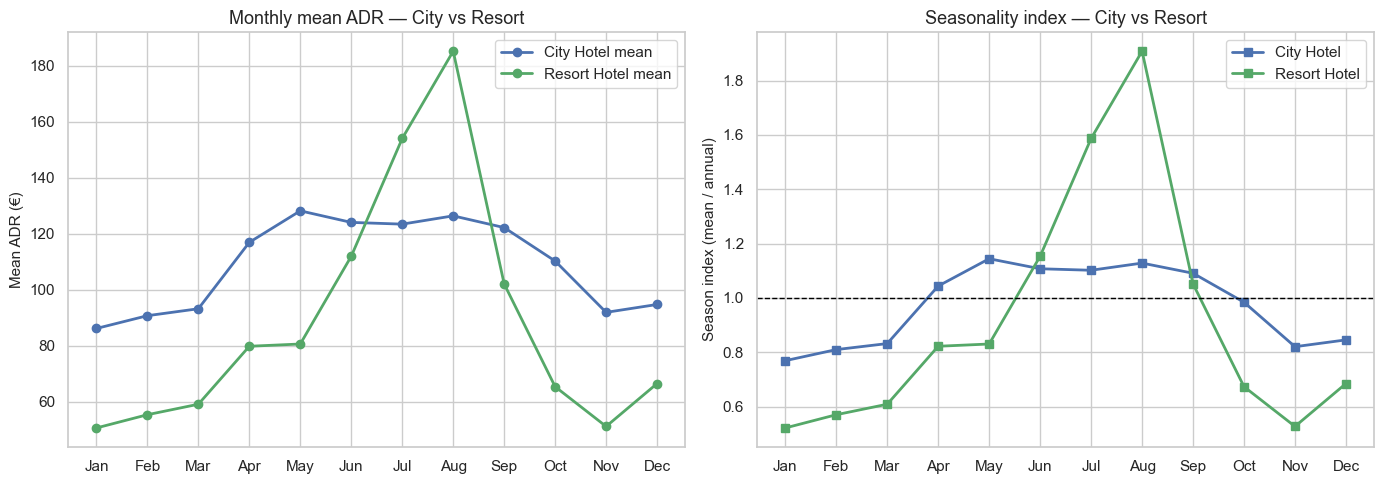

,city_mean,resort_mean,gap
arrival_date_month,,,
January,86.18,50.63,35.55
February,90.75,55.37,35.38
March,93.23,59.11,34.12
April,116.96,79.83,37.13
May,128.21,80.64,47.58
June,124.08,111.99,12.09
July,123.46,154.07,-30.61
August,126.42,185.26,-58.84
September,122.23,102.09,20.13


City Hotel — Peak: May (128,21 €) | Low: January (86,18 €) | Spread: 48,8%
Resort Hotel — Peak: August (185,26 €) | Low: January (50,63 €) | Spread: 265,9%


In [4]:
# 1.1 Monthly trend overlay City vs Resort
monthly_by_h = (
    stay.groupby(["hotel", "arrival_date_month"], observed=True)["adr"]
    .agg(bookings="count", mean_adr="mean", median_adr="median", std_adr="std")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for h in HOTELS:
    m = (
        monthly_by_h[monthly_by_h["hotel"] == h]
        .set_index("arrival_date_month")
        .reindex(MONTH_ORDER)
    )
    ax.plot(
        range(12), m["mean_adr"], marker="o", color=HOTEL_COLORS[h],
        label=f"{h} mean", lw=2,
    )
ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in MONTH_ORDER])
ax.set_ylabel("Mean ADR (€)")
ax.set_title("Monthly mean ADR — City vs Resort")
ax.legend()

ax = axes[1]
for h in HOTELS:
    g = subset(h)
    m = (
        g.groupby("arrival_date_month", observed=True)["adr"].mean()
        .reindex(MONTH_ORDER)
    )
    idx = m / g["adr"].mean()
    ax.plot(range(12), idx, marker="s", color=HOTEL_COLORS[h], label=h, lw=2)
ax.axhline(1.0, color="black", ls="--", lw=1)
ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in MONTH_ORDER])
ax.set_ylabel("Season index (mean / annual)")
ax.set_title("Seasonality index — City vs Resort")
ax.legend()

savefig("01_monthly_adr_overlay.png")
plt.show()

# Gap City − Resort by month
city_m = city.groupby("arrival_date_month", observed=True)["adr"].mean().reindex(MONTH_ORDER)
resort_m = resort.groupby("arrival_date_month", observed=True)["adr"].mean().reindex(MONTH_ORDER)
gap_m = (city_m - resort_m).rename("city_minus_resort")
display(pd.DataFrame({"city_mean": city_m, "resort_mean": resort_m, "gap": gap_m}).round(2))

for h in HOTELS:
    g = subset(h)
    m = g.groupby("arrival_date_month", observed=True)["adr"].mean().reindex(MONTH_ORDER)
    print(
        f"{h} — Peak: {m.idxmax()} ({fmt_eur(m.max())}) | "
        f"Low: {m.idxmin()} ({fmt_eur(m.min())}) | "
        f"Spread: {fmt_pct(m.max() / m.min() - 1)}"
    )

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26260\3662254940.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels([m[:3] for m in MONTH_ORDER])


Saved: reports\figures\17b\02_monthly_adr_boxplot_by_hotel.png


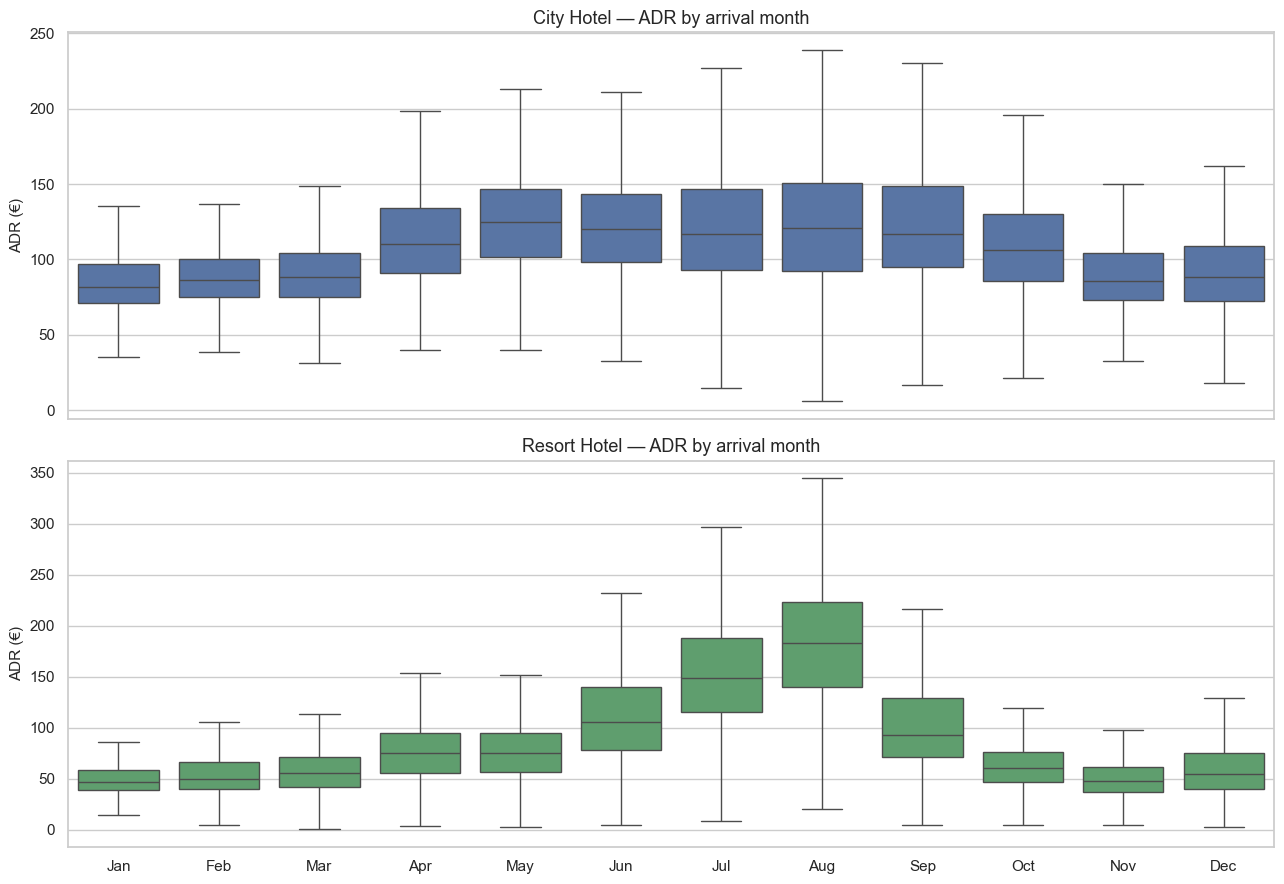

In [5]:
# 1.2 Box plot ADR theo tháng — facet 2 hotel
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for ax, h in zip(axes, HOTELS):
    sns.boxplot(
        data=subset(h),
        x="arrival_date_month",
        y="adr",
        order=MONTH_ORDER,
        showfliers=False,
        color=HOTEL_COLORS[h],
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel("ADR (€)")
    ax.set_title(f"{h} — ADR by arrival month")
axes[1].set_xticklabels([m[:3] for m in MONTH_ORDER])
savefig("02_monthly_adr_boxplot_by_hotel.png")
plt.show()

,hotel,day_type,bookings,mean_adr,median_adr
0,City Hotel,Weekday,19714,111.52,104.55
1,City Hotel,Weekend,14560,112.76,105.30
2,Resort Hotel,Weekday,13454,94.13,74.00
3,Resort Hotel,Weekend,10338,100.94,82.80


City Hotel: Weekend−Weekday mean 1,24 € (1,1%) | MW p=2.10e-02
Resort Hotel: Weekend−Weekday mean 6,81 € (7,2%) | MW p=2.89e-33


,delta_mean,delta_median,delta_pct,mannwhitney_p
hotel,,,,
City Hotel,1.2392,0.75,0.0111,0.021
Resort Hotel,6.8110,8.80,0.0724,0.000


Saved: reports\figures\17b\03_weekend_weekday_by_hotel.png


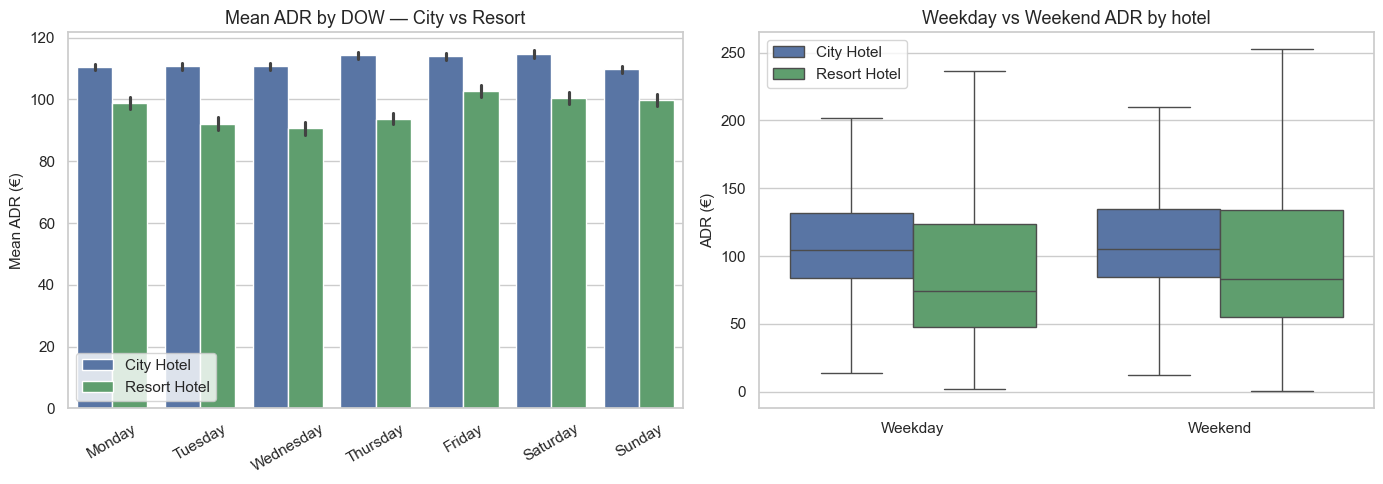

In [6]:
# 1.3 Weekend vs weekday — so sánh 2 phân khúc
wd_rows = []
for h in HOTELS:
    g = subset(h)
    for is_we, label in [(False, "Weekday"), (True, "Weekend")]:
        s = g.loc[g["is_weekend"] == is_we, "adr"]
        wd_rows.append({
            "hotel": h, "day_type": label,
            "bookings": len(s), "mean_adr": s.mean(), "median_adr": s.median(),
        })
wd = pd.DataFrame(wd_rows)
display(wd.round(2))

prem = []
for h in HOTELS:
    g = subset(h)
    d_mean = g.loc[g["is_weekend"], "adr"].mean() - g.loc[~g["is_weekend"], "adr"].mean()
    d_med = g.loc[g["is_weekend"], "adr"].median() - g.loc[~g["is_weekend"], "adr"].median()
    base = g.loc[~g["is_weekend"], "adr"].mean()
    u, p = stats.mannwhitneyu(
        g.loc[g["is_weekend"], "adr"], g.loc[~g["is_weekend"], "adr"], alternative="two-sided"
    )
    prem.append({
        "hotel": h, "delta_mean": d_mean, "delta_median": d_med,
        "delta_pct": d_mean / base, "mannwhitney_p": p,
    })
    print(f"{h}: Weekend−Weekday mean {fmt_eur(d_mean)} ({fmt_pct(d_mean / base)}) | MW p={p:.2e}")
premium_tbl = pd.DataFrame(prem).set_index("hotel")
display(premium_tbl.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.barplot(
    data=stay, x="day_of_week", y="adr", hue="hotel",
    order=DAY_ORDER, hue_order=HOTELS, palette=HOTEL_COLORS,
    estimator="mean", errorbar=("ci", 95), ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("Mean ADR (€)")
ax.set_title("Mean ADR by DOW — City vs Resort")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="")

ax = axes[1]
plot_df = stay.assign(
    day_type=stay["is_weekend"].map({True: "Weekend", False: "Weekday"})
)
sns.boxplot(
    data=plot_df, x="day_type", y="adr", hue="hotel",
    order=["Weekday", "Weekend"], hue_order=HOTELS,
    palette=HOTEL_COLORS, showfliers=False, ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("ADR (€)")
ax.set_title("Weekday vs Weekend ADR by hotel")
ax.legend(title="")
savefig("03_weekend_weekday_by_hotel.png")
plt.show()

Saved: reports\figures\17b\04a_heatmap_month_dow_by_hotel.png


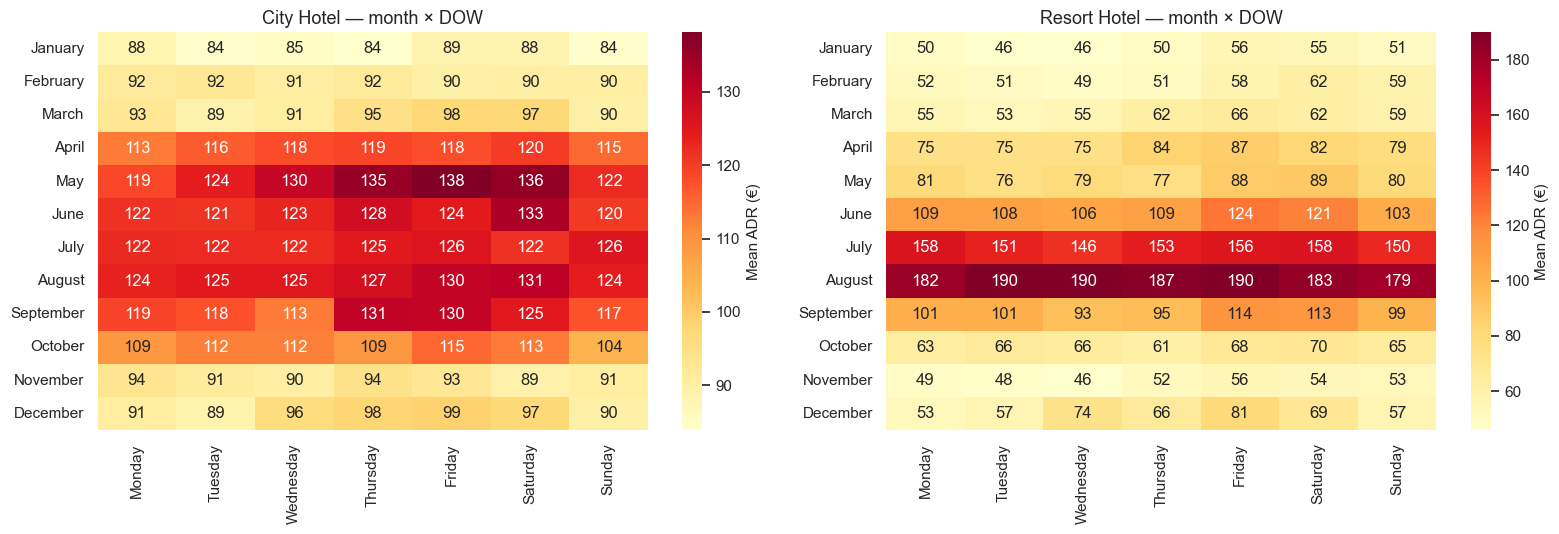

,weekday_adr,weekend_adr,delta,delta_pct,hotel
arrival_date_month,,,,,
January,85.48,87.10,1.62,0.02,City Hotel
February,91.53,89.95,-1.58,-0.02,City Hotel
March,92.02,95.05,3.03,0.03,City Hotel
April,116.37,117.64,1.27,0.01,City Hotel
May,126.09,131.52,5.43,0.04,City Hotel
June,123.50,124.99,1.49,0.01,City Hotel
July,122.84,124.19,1.35,0.01,City Hotel
August,125.13,128.39,3.26,0.03,City Hotel
September,120.64,124.48,3.84,0.03,City Hotel


Saved: reports\figures\17b\04b_weekend_premium_by_month_compare.png


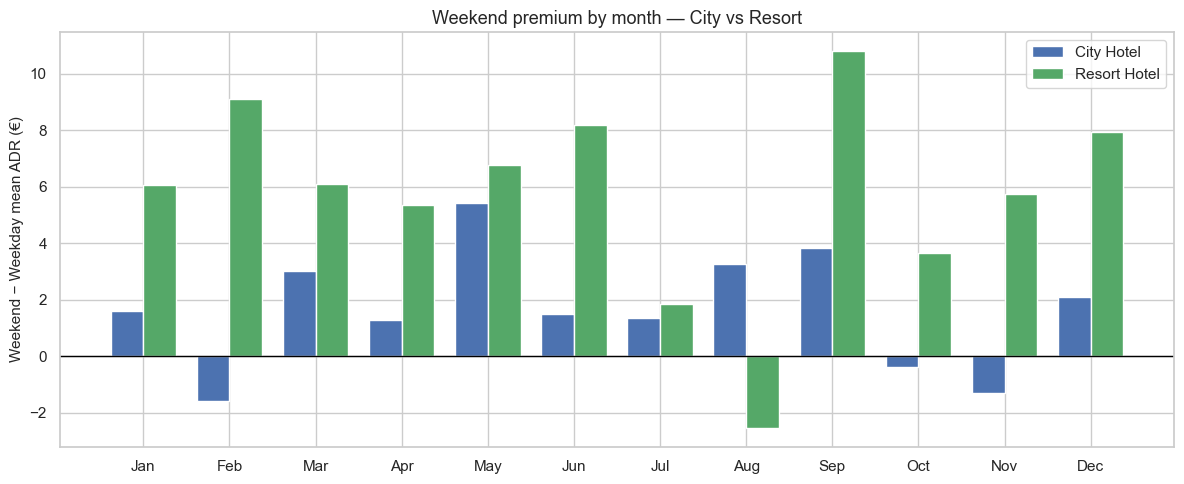

In [7]:
# 1.4 Heatmap month×DOW từng hotel + weekend premium by month so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ax, h in zip(axes, HOTELS):
    g = subset(h)
    heat = (
        g.pivot_table(
            index="arrival_date_month", columns="day_of_week",
            values="adr", aggfunc="mean", observed=True,
        )
        .reindex(index=MONTH_ORDER, columns=DAY_ORDER)
    )
    sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
                cbar_kws={"label": "Mean ADR (€)"})
    ax.set_title(f"{h} — month × DOW")
    ax.set_xlabel("")
    ax.set_ylabel("")
savefig("04a_heatmap_month_dow_by_hotel.png")
plt.show()

# Weekend premium by month — overlay bars
wb_list = []
for h in HOTELS:
    g = subset(h)
    wb = (
        g.groupby(["arrival_date_month", "is_weekend"], observed=True)["adr"]
        .mean()
        .unstack("is_weekend")
        .reindex(MONTH_ORDER)
    )
    wb.columns = ["weekday_adr", "weekend_adr"]
    wb["delta"] = wb["weekend_adr"] - wb["weekday_adr"]
    wb["delta_pct"] = wb["delta"] / wb["weekday_adr"]
    wb["hotel"] = h
    wb_list.append(wb)
weekend_by_month = pd.concat(wb_list)
display(weekend_by_month.round(2))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(12)
w = 0.38
for i, h in enumerate(HOTELS):
    d = weekend_by_month.loc[weekend_by_month["hotel"] == h, "delta"].reindex(MONTH_ORDER)
    ax.bar(x + (i - 0.5) * w, d.values, width=w, color=HOTEL_COLORS[h], label=h)
ax.axhline(0, color="black", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([m[:3] for m in MONTH_ORDER])
ax.set_ylabel("Weekend − Weekday mean ADR (€)")
ax.set_title("Weekend premium by month — City vs Resort")
ax.legend()
savefig("04b_weekend_premium_by_month_compare.png")
plt.show()

## 2. Lead-time vs ADR — theo phân khúc

So sánh đường cong early-bird / last-minute giữa City và Resort (có control theo mùa).

City Hotel: Spearman ρ=-0.001 (p=8.93e-01) | Pearson r=-0.034 (p=4.91e-10)
Resort Hotel: Spearman ρ=0.191 (p=4.11e-195) | Pearson r=0.066 (p=1.57e-24)


,spearman,spearman_p,pearson,pearson_p
hotel,,,,
City Hotel,-0.0007,0.8925,-0.0336,0.0
Resort Hotel,0.1914,0.0000,0.0662,0.0


bookings  mean_adr  median_adr    p25     p75
hotel        lead_bin                                               
City Hotel   0-7           7899    111.49      102.80  80.10  136.00
             8-30          7167    115.84      108.00  86.40  139.20
             31-90         9466    110.38      102.64  80.34  132.59
             91-180        6820    113.36      108.00  88.40  130.67
             180+          2922    106.60       99.45  85.00  120.59
Resort Hotel 0-7           7039     81.27       63.00  44.00  100.00
             8-30          4289    100.08       75.46  49.74  136.67
             31-90         5000    107.42       87.00  56.00  145.60
             91-180        4265    107.75       92.00  60.65  142.00
             180+          3199     97.54       84.58  61.16  123.42

Saved: reports\figures\17b\05_lead_time_vs_adr_by_hotel.png


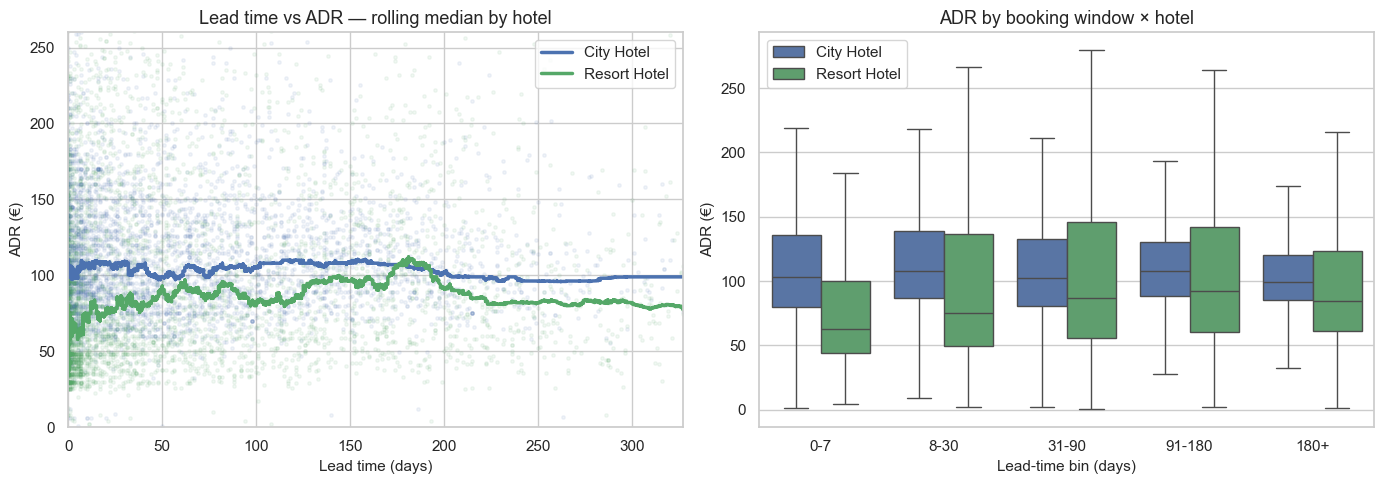

In [8]:
# 2.1 Correlation + lead bins by hotel
corr_rows = []
for h in HOTELS:
    g = subset(h)
    sp_r, sp_p = stats.spearmanr(g["lead_time"], g["adr"])
    pe_r, pe_p = stats.pearsonr(g["lead_time"], g["adr"])
    corr_rows.append({
        "hotel": h, "spearman": sp_r, "spearman_p": sp_p,
        "pearson": pe_r, "pearson_p": pe_p,
    })
    print(f"{h}: Spearman ρ={sp_r:.3f} (p={sp_p:.2e}) | Pearson r={pe_r:.3f} (p={pe_p:.2e})")
corr_tbl = pd.DataFrame(corr_rows).set_index("hotel")
display(corr_tbl.round(4))

lead_summary = (
    stay.groupby(["hotel", "lead_bin"], observed=True)["adr"]
    .agg(bookings="count", mean_adr="mean", median_adr="median",
         p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75))
)
display(lead_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for h in HOTELS:
    g = subset(h)
    ordered = g.sort_values("lead_time")
    window = max(300, len(ordered) // 40)
    roll = ordered["adr"].rolling(window=window, center=True, min_periods=80).median()
    sample = g.sample(n=min(4_000, len(g)), random_state=42)
    ax.scatter(sample["lead_time"], sample["adr"], alpha=0.08, s=6, color=HOTEL_COLORS[h])
    ax.plot(ordered["lead_time"], roll, color=HOTEL_COLORS[h], lw=2.5, label=h)
ax.set_xlim(0, stay["lead_time"].quantile(0.99))
ax.set_ylim(0, stay["adr"].quantile(0.99))
ax.set_xlabel("Lead time (days)")
ax.set_ylabel("ADR (€)")
ax.set_title("Lead time vs ADR — rolling median by hotel")
ax.legend()

ax = axes[1]
sns.boxplot(
    data=stay, x="lead_bin", y="adr", hue="hotel",
    order=LEAD_LABELS, hue_order=HOTELS, palette=HOTEL_COLORS,
    showfliers=False, ax=ax,
)
ax.set_xlabel("Lead-time bin (days)")
ax.set_ylabel("ADR (€)")
ax.set_title("ADR by booking window × hotel")
ax.legend(title="")
savefig("05_lead_time_vs_adr_by_hotel.png")
plt.show()

Saved: reports\figures\17b\06_lead_season_by_hotel.png


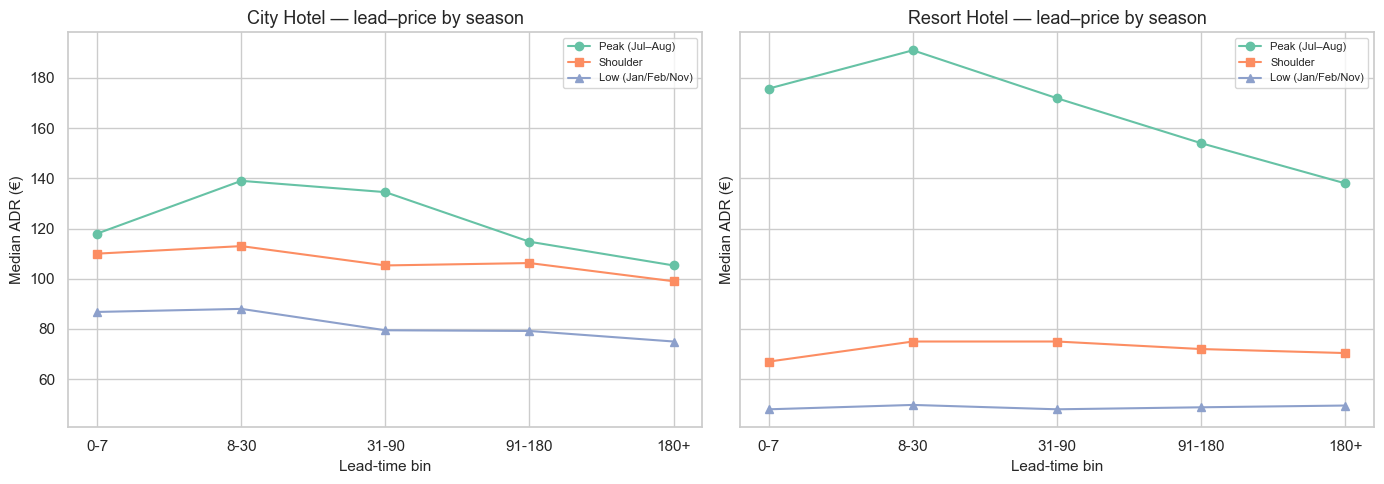

hotel,City Hotel,Resort Hotel
lead_bin,,
0-7,102.80,63.00
8-30,108.00,75.46
31-90,102.64,87.00
91-180,108.00,92.00
180+,99.45,84.58


In [9]:
# 2.2 Lead × season control — curve overlay per hotel
stay["season_group"] = np.where(
    stay["arrival_date_month"].isin(["July", "August"]),
    "Peak (Jul–Aug)",
    np.where(
        stay["arrival_date_month"].isin(["January", "February", "November"]),
        "Low (Jan/Feb/Nov)",
        "Shoulder",
    ),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
season_cols = ["Peak (Jul–Aug)", "Shoulder", "Low (Jan/Feb/Nov)"]
markers = {"Peak (Jul–Aug)": "o", "Shoulder": "s", "Low (Jan/Feb/Nov)": "^"}

for ax, h in zip(axes, HOTELS):
    g = stay[stay["hotel"] == h]
    ls = (
        g.groupby(["lead_bin", "season_group"], observed=True)["adr"]
        .median()
        .unstack("season_group")
        .reindex(LEAD_LABELS)
    )
    for col in season_cols:
        if col in ls.columns:
            ax.plot(LEAD_LABELS, ls[col], marker=markers[col], label=col)
    ax.set_title(f"{h} — lead–price by season")
    ax.set_xlabel("Lead-time bin")
    ax.set_ylabel("Median ADR (€)")
    ax.legend(fontsize=8)
savefig("06_lead_season_by_hotel.png")
plt.show()

# Median ADR lead×hotel table
lead_hotel = (
    stay.groupby(["lead_bin", "hotel"], observed=True)["adr"]
    .median()
    .unstack("hotel")
    .reindex(LEAD_LABELS)
)
display(lead_hotel.round(2))

Saved: reports\figures\17b\07_lead_by_segment_by_hotel.png


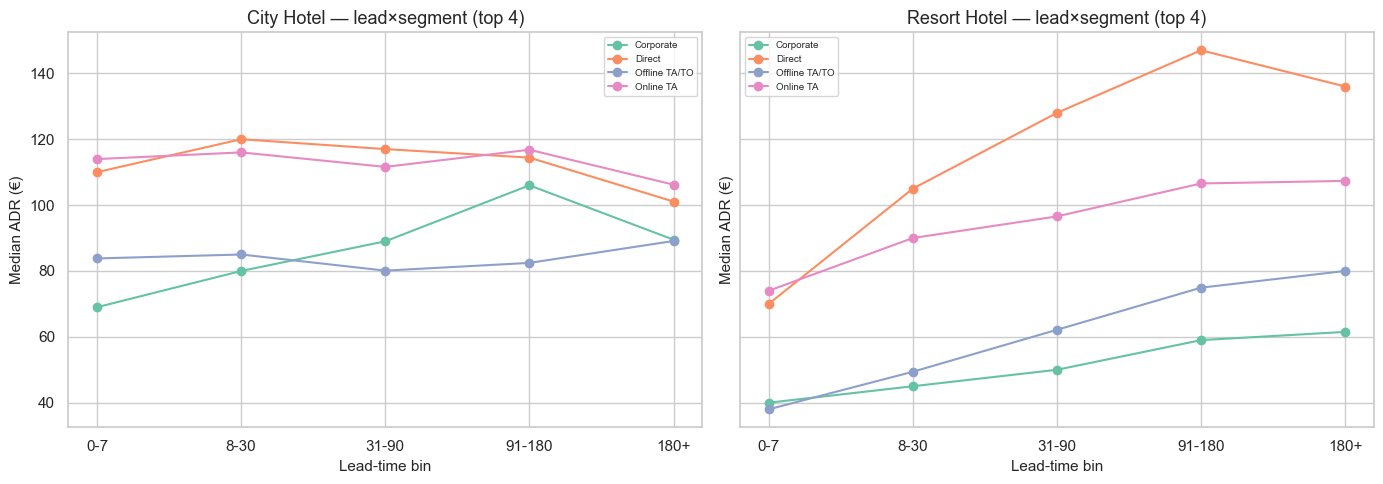

City Hotel: last-minute (0-7) med 102,80 € | early-bird (180+) 99,45 € | gap 3,35 €
Resort Hotel: last-minute (0-7) med 63,00 € | early-bird (180+) 84,58 € | gap -21,58 €


In [10]:
# 2.3 Lead curve by market segment — top segments within each hotel
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, h in zip(axes, HOTELS):
    g = subset(h)
    top_seg = g["market_segment"].value_counts().head(4).index.tolist()
    seg = g[g["market_segment"].isin(top_seg)]
    lead_seg = (
        seg.groupby(["lead_bin", "market_segment"], observed=True)["adr"]
        .median()
        .unstack("market_segment")
        .reindex(LEAD_LABELS)
    )
    for col in lead_seg.columns:
        ax.plot(LEAD_LABELS, lead_seg[col], marker="o", label=col)
    ax.set_title(f"{h} — lead×segment (top 4)")
    ax.set_xlabel("Lead-time bin")
    ax.set_ylabel("Median ADR (€)")
    ax.legend(fontsize=7, title="")
savefig("07_lead_by_segment_by_hotel.png")
plt.show()

for h in HOTELS:
    g = subset(h)
    early = g[g["lead_bin"] == "180+"]["adr"]
    late = g[g["lead_bin"] == "0-7"]["adr"]
    print(
        f"{h}: last-minute (0-7) med {fmt_eur(late.median())} | "
        f"early-bird (180+) {fmt_eur(early.median())} | "
        f"gap {fmt_eur(late.median() - early.median())}"
    )

## 3. Room type premium & upsell — theo phân khúc

Ladder phòng và opportunity free upgrade **riêng** từng hotel (cơ cấu phòng / giá khác nhau).


=== City Hotel room ladder ===


,median_adr,rank,bookings_reserved,premium_vs_prev
B,86.93,1,620,0.00
A,95.40,2,24531,8.47
K,99.00,3,0,3.60
C,110.00,4,5,11.00
D,130.05,5,6805,20.05
E,159.30,6,965,29.25
F,189.00,7,1037,29.70
G,226.00,8,311,37.00



=== Resort Hotel room ladder ===


,median_adr,rank,bookings_reserved,premium_vs_prev
A,60.00,1,13035,0.00
I,79.21,2,0,19.21
D,82.69,3,4809,3.48
E,96.00,4,3239,13.31
B,110.00,5,3,14.00
F,119.00,6,851,9.00
L,150.00,7,3,31.00
G,152.00,8,919,2.00
C,161.24,9,586,9.24
H,175.00,10,347,13.76


Saved: reports\figures\17b\08_room_price_ladder_by_hotel.png


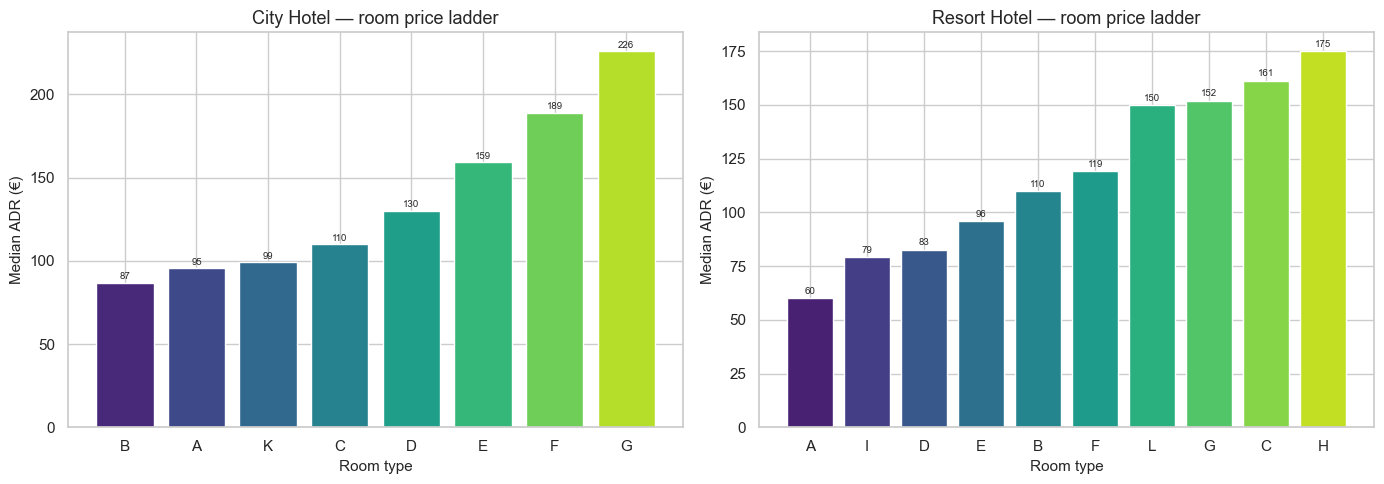

In [11]:
# 3.1 Room ladder per hotel
room_tables = {}
medians_map = {}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, h in zip(axes, HOTELS):
    g = subset(h)
    reserved_med = g.groupby("reserved_room_type", observed=True)["adr"].median()
    assigned_med = g.groupby("assigned_room_type", observed=True)["adr"].median()
    reserved_n = g.groupby("reserved_room_type", observed=True)["adr"].count()
    all_types = sorted(set(reserved_med.index) | set(assigned_med.index))
    medians = {
        rt: float(reserved_med[rt]) if rt in reserved_med.index else float(assigned_med[rt])
        for rt in all_types
    }
    ladder = pd.Series(medians).sort_values()
    rank_map = {rt: i + 1 for i, rt in enumerate(ladder.index)}
    room_table = pd.DataFrame({
        "median_adr": ladder.values,
        "rank": [rank_map[rt] for rt in ladder.index],
        "bookings_reserved": [int(reserved_n.get(rt, 0)) for rt in ladder.index],
    }, index=ladder.index)
    room_table["premium_vs_prev"] = room_table["median_adr"].diff().fillna(0)
    room_tables[h] = room_table
    medians_map[h] = medians
    print(f"\n=== {h} room ladder ===")
    display(room_table.round(2))

    ax.bar(
        room_table.index.astype(str), room_table["median_adr"],
        color=sns.color_palette("viridis", n_colors=len(room_table)),
    )
    for i, (_, row) in enumerate(room_table.iterrows()):
        ax.text(i, row["median_adr"] + 2, f"{row['median_adr']:.0f}", ha="center", fontsize=7)
    ax.set_ylabel("Median ADR (€)")
    ax.set_xlabel("Room type")
    ax.set_title(f"{h} — room price ladder")
savefig("08_room_price_ladder_by_hotel.png")
plt.show()

In [12]:
# 3.2 Mis-match / upsell opportunity per hotel
upsell_kpi = []

for h in HOTELS:
    g = subset(h)
    medians = medians_map[h]
    room_table = room_tables[h]
    mm = g[~g["room_match"]].copy()
    mm["r_med"] = mm["reserved_room_type"].map(medians)
    mm["a_med"] = mm["assigned_room_type"].map(medians)
    mm["shift_type"] = np.where(mm["a_med"] > mm["r_med"], "upgrade", "downgrade")
    mm["premium_gap"] = mm["a_med"] - mm["r_med"]

    cheap_types = (
        room_table[room_table["bookings_reserved"] > 0]
        .nsmallest(2, "median_adr")
        .index.tolist()
    )
    mm["free_upgrade_proxy"] = (
        mm["reserved_room_type"].isin(cheap_types) & (mm["shift_type"] == "upgrade")
    )

    n_stay = len(g)
    n_mm = len(mm)
    n_up = int((mm["shift_type"] == "upgrade").sum())
    n_down = int((mm["shift_type"] == "downgrade").sum())
    n_free = int(mm["free_upgrade_proxy"].sum())
    free = mm[mm["free_upgrade_proxy"]]
    opp_booking = float((free["premium_gap"] * free["total_nights"]).sum()) if len(free) else 0.0
    mean_prem = float(free["premium_gap"].mean()) if len(free) else 0.0

    print(f"\n=== {h} ===")
    print(f"Mis-match: {fmt_pct(n_mm / n_stay)} ({fmt_int(n_mm)}/{fmt_int(n_stay)})")
    print(f"Upgrade: {fmt_int(n_up)} | Downgrade: {fmt_int(n_down)}")
    print(f"Free upgrade proxy {cheap_types}: {fmt_int(n_free)} | Opp: {fmt_eur(opp_booking)}")

    upsell_kpi.append({
        "hotel": h, "n_stay": n_stay, "mismatch_rate": n_mm / n_stay,
        "upgrade_share_of_mm": n_up / n_mm if n_mm else 0,
        "free_upgrade_n": n_free, "upsell_opp_eur": opp_booking,
        "mean_free_premium": mean_prem,
        "adr_match": g.loc[g["room_match"], "adr"].mean(),
        "adr_mismatch": mm["adr"].mean() if n_mm else np.nan,
    })

upsell_df = pd.DataFrame(upsell_kpi).set_index("hotel")
display(upsell_df.round(2))


=== City Hotel ===
Mis-match: 13,8% (4.729/34.274)
Upgrade: 3.900 | Downgrade: 829
Free upgrade proxy ['B', 'A']: 3.399 | Opp: 348.140,41 €

=== Resort Hotel ===
Mis-match: 23,9% (5.695/23.792)
Upgrade: 5.524 | Downgrade: 171
Free upgrade proxy ['A', 'D']: 5.112 | Opp: 681.861,25 €


,n_stay,mismatch_rate,upgrade_share_of_mm,free_upgrade_n,upsell_opp_eur,mean_free_premium,adr_match,adr_mismatch
hotel,,,,,,,,
City Hotel,34274,0.14,0.82,3399,348140.41,38.97,112.61,108.52
Resort Hotel,23792,0.24,0.97,5112,681861.25,42.18,103.61,76.37


Saved: reports\figures\17b\09_upsell_by_hotel.png


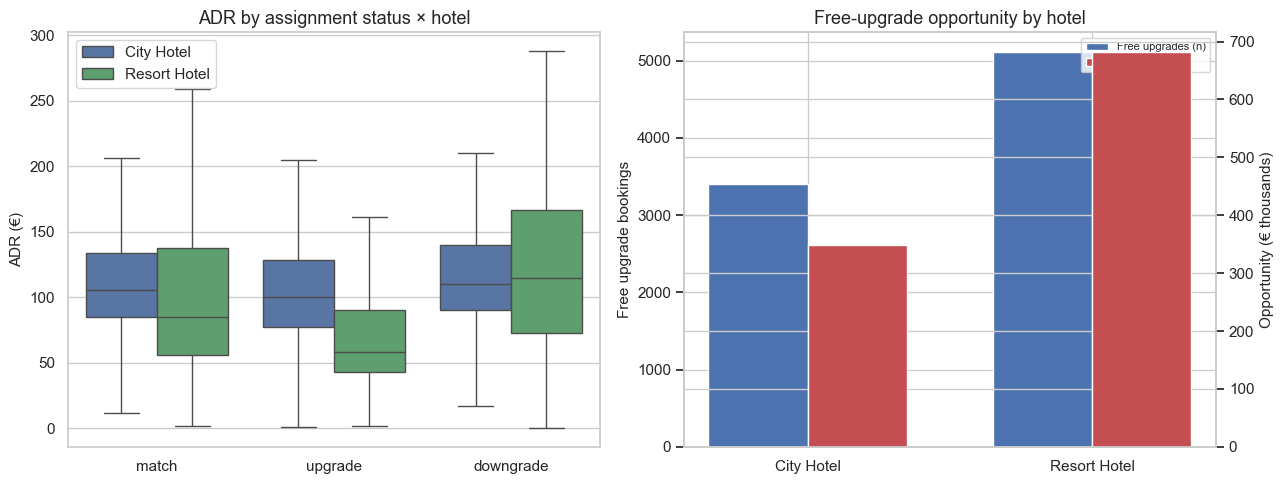

In [13]:
# 3.3 Status ADR + opportunity snapshot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Build status for all
cmp_parts = []
for h in HOTELS:
    g = subset(h)
    medians = medians_map[h]
    mm = g[~g["room_match"]].copy()
    mm["r_med"] = mm["reserved_room_type"].map(medians)
    mm["a_med"] = mm["assigned_room_type"].map(medians)
    mm["shift_type"] = np.where(mm["a_med"] > mm["r_med"], "upgrade", "downgrade")
    part = g.copy()
    part["status"] = "match"
    part.loc[mm.index, "status"] = mm["shift_type"]
    cmp_parts.append(part)
cmp = pd.concat(cmp_parts)

status_order = ["match", "upgrade", "downgrade"]
sns.boxplot(
    data=cmp, x="status", y="adr", hue="hotel",
    order=status_order, hue_order=HOTELS, palette=HOTEL_COLORS,
    showfliers=False, ax=axes[0],
)
axes[0].set_title("ADR by assignment status × hotel")
axes[0].set_xlabel("")
axes[0].set_ylabel("ADR (€)")
axes[0].legend(title="")

x = np.arange(len(HOTELS))
w = 0.35
axes[1].bar(
    x - w / 2, upsell_df["free_upgrade_n"], width=w,
    color="#4C72B0", label="Free upgrades (n)",
)
ax2 = axes[1].twinx()
ax2.bar(
    x + w / 2, upsell_df["upsell_opp_eur"] / 1000, width=w,
    color="#C44E52", label="Opp. (€k)",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(HOTELS)
axes[1].set_ylabel("Free upgrade bookings")
ax2.set_ylabel("Opportunity (€ thousands)")
axes[1].set_title("Free-upgrade opportunity by hotel")
# combined legend
h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[1].legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)

savefig("09_upsell_by_hotel.png")
plt.show()

## 4. Biểu đồ so sánh chéo bổ sung

Các view giúp **đọc lệch chiến lược** giữa City và Resort (không chỉ chạy lại từng bên):

- Gap / heatmap / KPI profile
- **Slope chart** — `customer_type` & `deposit_type`
- **Cancel-adjusted** — ADR Stay vs Canceled
- **Small multiples** — weekend premium theo `market_segment`

Saved: reports\figures\17b\10_adr_gap_month_dow.png


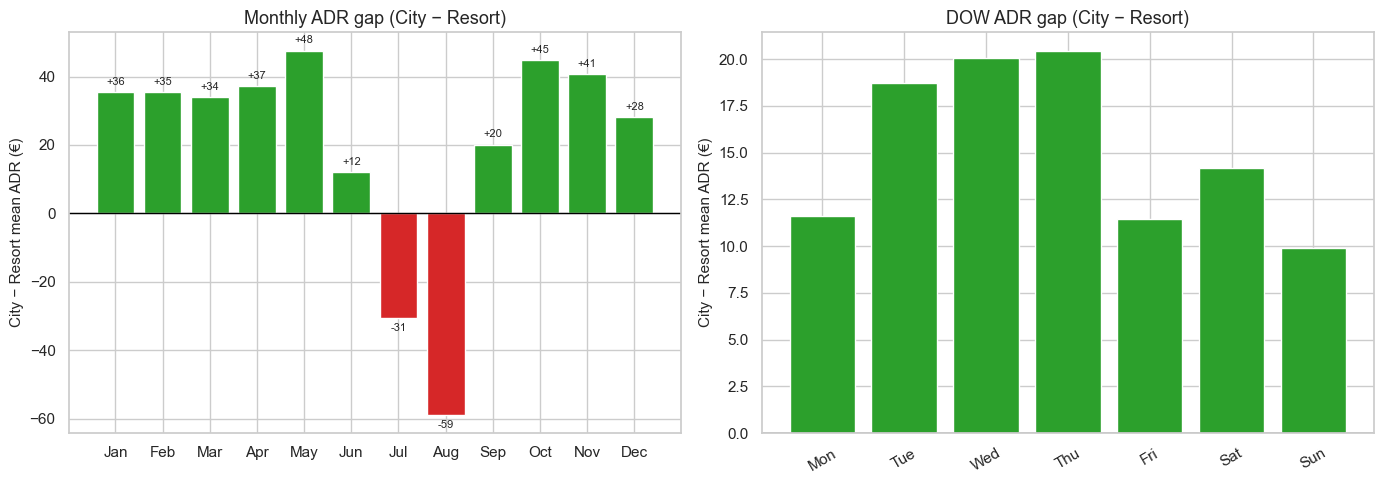

,city,resort,gap
day_of_week,,,
Monday,110.48,98.86,11.62
Tuesday,110.67,91.97,18.70
Wednesday,110.75,90.71,20.04
Thursday,114.22,93.82,20.41
Friday,114.04,102.62,11.43
Saturday,114.61,100.44,14.17
Sunday,109.71,99.79,9.91


In [14]:
# 4.1 ADR gap (City − Resort) by month + by DOW
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in gap_m.values]
ax.bar(range(12), gap_m.values, color=colors)
ax.axhline(0, color="black", lw=1)
ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in MONTH_ORDER])
ax.set_ylabel("City − Resort mean ADR (€)")
ax.set_title("Monthly ADR gap (City − Resort)")
for i, v in enumerate(gap_m.values):
    ax.text(i, v + (1.5 if v >= 0 else -1.5), f"{v:+.0f}", ha="center", fontsize=8,
            va="bottom" if v >= 0 else "top")

ax = axes[1]
city_d = city.groupby("day_of_week", observed=True)["adr"].mean().reindex(DAY_ORDER)
resort_d = resort.groupby("day_of_week", observed=True)["adr"].mean().reindex(DAY_ORDER)
gap_d = city_d - resort_d
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in gap_d.values]
ax.bar(range(7), gap_d.values, color=colors)
ax.axhline(0, color="black", lw=1)
ax.set_xticks(range(7))
ax.set_xticklabels([d[:3] for d in DAY_ORDER], rotation=30)
ax.set_ylabel("City − Resort mean ADR (€)")
ax.set_title("DOW ADR gap (City − Resort)")

savefig("10_adr_gap_month_dow.png")
plt.show()
display(pd.DataFrame({"city": city_d, "resort": resort_d, "gap": gap_d}).round(2))

Saved: reports\figures\17b\11_lead_month_heatmap_gap.png


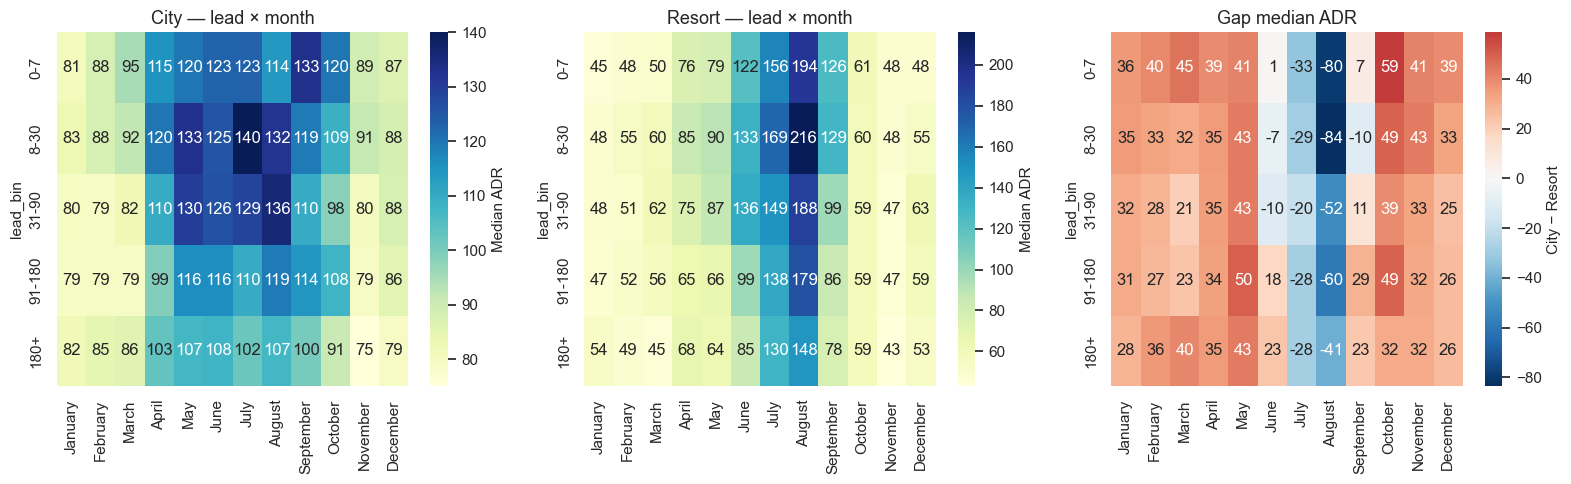

In [15]:
# 4.2 Dual heatmap: mean ADR City vs Resort (month × lead) + gap heatmap
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

heat_c = (
    city.pivot_table(index="lead_bin", columns="arrival_date_month",
                     values="adr", aggfunc="median", observed=True)
    .reindex(index=LEAD_LABELS, columns=MONTH_ORDER)
)
heat_r = (
    resort.pivot_table(index="lead_bin", columns="arrival_date_month",
                       values="adr", aggfunc="median", observed=True)
    .reindex(index=LEAD_LABELS, columns=MONTH_ORDER)
)
heat_gap = heat_c - heat_r

sns.heatmap(heat_c, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[0],
            cbar_kws={"label": "Median ADR"})
axes[0].set_title("City — lead × month")
axes[0].set_xlabel("")

sns.heatmap(heat_r, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[1],
            cbar_kws={"label": "Median ADR"})
axes[1].set_title("Resort — lead × month")
axes[1].set_xlabel("")

sns.heatmap(heat_gap, annot=True, fmt=".0f", cmap="RdBu_r", center=0, ax=axes[2],
            cbar_kws={"label": "City − Resort"})
axes[2].set_title("Gap median ADR")
axes[2].set_xlabel("")

savefig("11_lead_month_heatmap_gap.png")
plt.show()

,mean_adr,median_adr,weekend_premium,season_spread_pct,last_min_vs_early_gap,mismatch_rate_pct,upsell_opp_eur_k
City Hotel,112.05,105.0,1.24,0.49,3.35,13.80,348.14
Resort Hotel,97.09,77.5,6.81,2.66,-21.58,23.94,681.86


Saved: reports\figures\17b\12_kpi_profile_compare.png


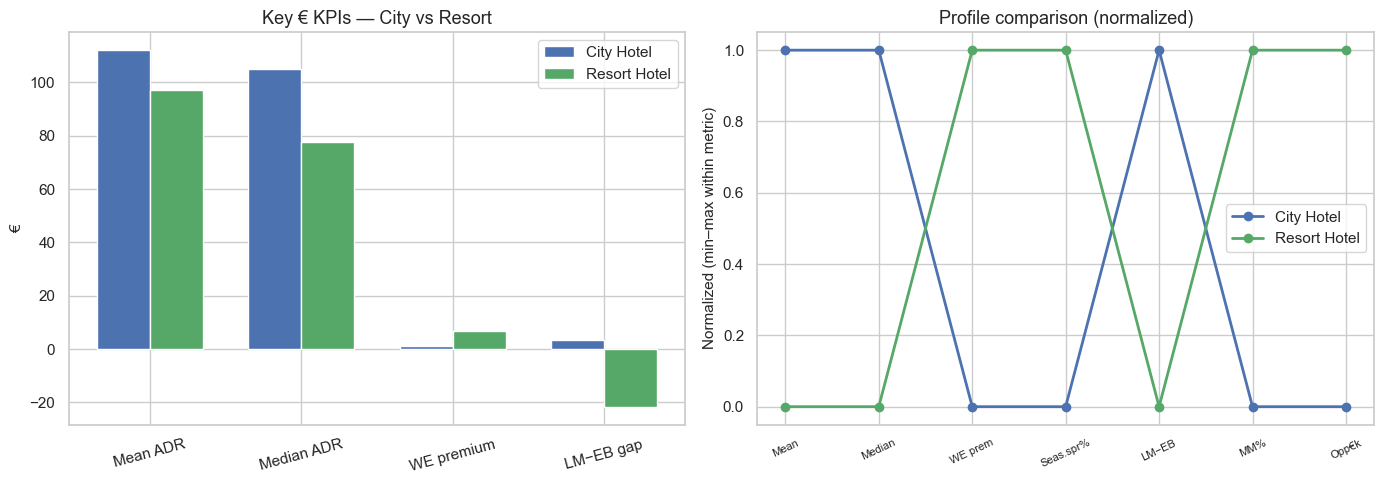

Saved: reports\figures\17b\kpi_compare_city_resort.csv


In [16]:
# 4.3 Slope chart: mean ADR by hotel across key dimensions
# Compact KPI radar-like grouped bars
kpi_compare = pd.DataFrame({
    "mean_adr": [city["adr"].mean(), resort["adr"].mean()],
    "median_adr": [city["adr"].median(), resort["adr"].median()],
    "weekend_premium": premium_tbl["delta_mean"].values,
    "season_spread_pct": [
        city.groupby("arrival_date_month", observed=True)["adr"].mean().max()
        / city.groupby("arrival_date_month", observed=True)["adr"].mean().min() - 1,
        resort.groupby("arrival_date_month", observed=True)["adr"].mean().max()
        / resort.groupby("arrival_date_month", observed=True)["adr"].mean().min() - 1,
    ],
    "last_min_vs_early_gap": [
        city.loc[city["lead_bin"] == "0-7", "adr"].median()
        - city.loc[city["lead_bin"] == "180+", "adr"].median(),
        resort.loc[resort["lead_bin"] == "0-7", "adr"].median()
        - resort.loc[resort["lead_bin"] == "180+", "adr"].median(),
    ],
    "mismatch_rate_pct": upsell_df["mismatch_rate"].values * 100,
    "upsell_opp_eur_k": upsell_df["upsell_opp_eur"].values / 1000,
}, index=HOTELS)
display(kpi_compare.round(2))

# Normalize 0-1 within each metric for parallel comparison chart
norm = kpi_compare.copy()
for c in norm.columns:
    lo, hi = norm[c].min(), norm[c].max()
    norm[c] = 0.5 if hi == lo else (norm[c] - lo) / (hi - lo)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
metrics = list(kpi_compare.columns)
x = np.arange(len(metrics))
w = 0.35
# z-score style display of raw values via twin? → just grouped bars of key € metrics
euro_cols = ["mean_adr", "median_adr", "weekend_premium", "last_min_vs_early_gap"]
xx = np.arange(len(euro_cols))
ax.bar(xx - w / 2, kpi_compare.loc["City Hotel", euro_cols], width=w,
       color=HOTEL_COLORS["City Hotel"], label="City Hotel")
ax.bar(xx + w / 2, kpi_compare.loc["Resort Hotel", euro_cols], width=w,
       color=HOTEL_COLORS["Resort Hotel"], label="Resort Hotel")
ax.set_xticks(xx)
ax.set_xticklabels(["Mean ADR", "Median ADR", "WE premium", "LM−EB gap"], rotation=15)
ax.set_ylabel("€")
ax.set_title("Key € KPIs — City vs Resort")
ax.legend()

ax = axes[1]
# Parallel coordinates (normalized)
for h in HOTELS:
    ax.plot(range(len(metrics)), norm.loc[h].values, marker="o", lw=2,
            color=HOTEL_COLORS[h], label=h)
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(
    ["Mean", "Median", "WE prem", "Seas.spr%", "LM−EB", "MM%", "Opp€k"],
    rotation=25, fontsize=8,
)
ax.set_ylabel("Normalized (min–max within metric)")
ax.set_title("Profile comparison (normalized)")
ax.legend()
ax.set_ylim(-0.05, 1.05)

savefig("12_kpi_profile_compare.png")
plt.show()
kpi_compare.to_csv(FIG_DIR / "kpi_compare_city_resort.csv")
print(f"Saved: {(FIG_DIR / 'kpi_compare_city_resort.csv').relative_to(ROOT)}")

Saved: reports\figures\17b\13_slope_customer_deposit.png


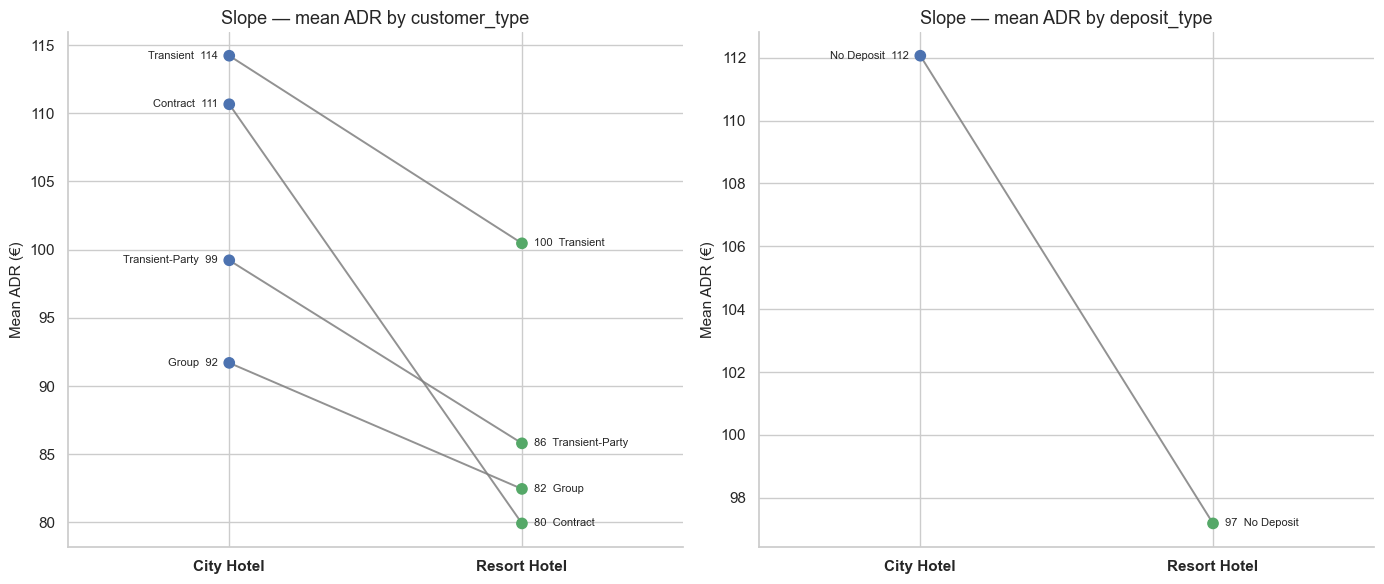

customer_type


bookings                mean_adr             
hotel           City Hotel Resort Hotel City Hotel Resort Hotel
customer_type                                                  
Contract            1065.0       1475.0     110.66        79.92
Group                228.0        213.0      91.70        82.45
Transient          28609.0      18960.0     114.22       100.47
Transient-Party     4372.0       3144.0      99.22        85.80

deposit_type


bookings                mean_adr             
hotel        City Hotel Resort Hotel City Hotel Resort Hotel
deposit_type                                                
No Deposit      34246.0      23714.0     112.06        97.18

In [17]:
# 4.4 Slope charts — mean ADR City vs Resort by customer_type & deposit_type
def slope_chart(ax, frame: pd.DataFrame, dim: str, title: str, min_n: int = 50) -> pd.DataFrame:
    tbl = (
        frame.groupby(["hotel", dim], observed=True)["adr"]
        .agg(bookings="count", mean_adr="mean", median_adr="median")
        .reset_index()
    )
    # giữ category có đủ volume ở cả 2 hotel
    ok = (
        tbl.groupby(dim)["bookings"].min().loc[lambda s: s >= min_n].index.tolist()
    )
    tbl = tbl[tbl[dim].isin(ok)].copy()
    cats = (
        tbl.groupby(dim)["mean_adr"].mean().sort_values(ascending=False).index.tolist()
    )

    x_pos = {"City Hotel": 0, "Resort Hotel": 1}
    for cat in cats:
        sub = tbl[tbl[dim] == cat].set_index("hotel")
        if not set(HOTELS).issubset(sub.index):
            continue
        y0 = sub.loc["City Hotel", "mean_adr"]
        y1 = sub.loc["Resort Hotel", "mean_adr"]
        ax.plot([0, 1], [y0, y1], color="#7f7f7f", lw=1.4, alpha=0.85, zorder=1)
        ax.scatter([0, 1], [y0, y1], s=55, zorder=2,
                   c=[HOTEL_COLORS["City Hotel"], HOTEL_COLORS["Resort Hotel"]])
        ax.text(-0.04, y0, f"{cat}  {y0:.0f}", ha="right", va="center", fontsize=8)
        ax.text(1.04, y1, f"{y1:.0f}  {cat}", ha="left", va="center", fontsize=8)

    ax.set_xlim(-0.55, 1.55)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["City Hotel", "Resort Hotel"], fontweight="bold")
    ax.set_ylabel("Mean ADR (€)")
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return tbl


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ct_slope = slope_chart(
    axes[0], stay, "customer_type",
    "Slope — mean ADR by customer_type",
)
dep_slope = slope_chart(
    axes[1], stay, "deposit_type",
    "Slope — mean ADR by deposit_type",
    min_n=30,
)
savefig("13_slope_customer_deposit.png")
plt.show()

print("customer_type")
display(ct_slope.pivot(index="customer_type", columns="hotel", values=["bookings", "mean_adr"]).round(2))
print("deposit_type")
display(dep_slope.pivot(index="deposit_type", columns="hotel", values=["bookings", "mean_adr"]).round(2))

,hotel,status_label,bookings,mean_adr,median_adr,p25,p75
0,City Hotel,Canceled,15451,118.58,112.05,89.25,139.5
1,City Hotel,Stay,34274,112.05,105.00,84.45,133.2
2,Resort Hotel,Canceled,7661,121.09,106.92,64.80,169.0
3,Resort Hotel,Stay,23792,97.09,77.50,51.80,129.0


City Hotel: cancel rate 31,1% | mean Stay 112,05 € vs Canceled 118,58 € | gap 6,53 € | MW p=1.28e-76
Resort Hotel: cancel rate 24,4% | mean Stay 97,09 € vs Canceled 121,09 € | gap 23,99 € | MW p=5.68e-180


,cancel_rate,mean_stay,mean_canceled,gap_canceled_minus_stay,median_gap,mannwhitney_p
hotel,,,,,,
City Hotel,0.3107,112.0501,118.5801,6.5300,7.05,0.0
Resort Hotel,0.2436,97.0930,121.0878,23.9948,29.42,0.0


Saved: reports\figures\17b\14_cancel_adjusted_adr.png


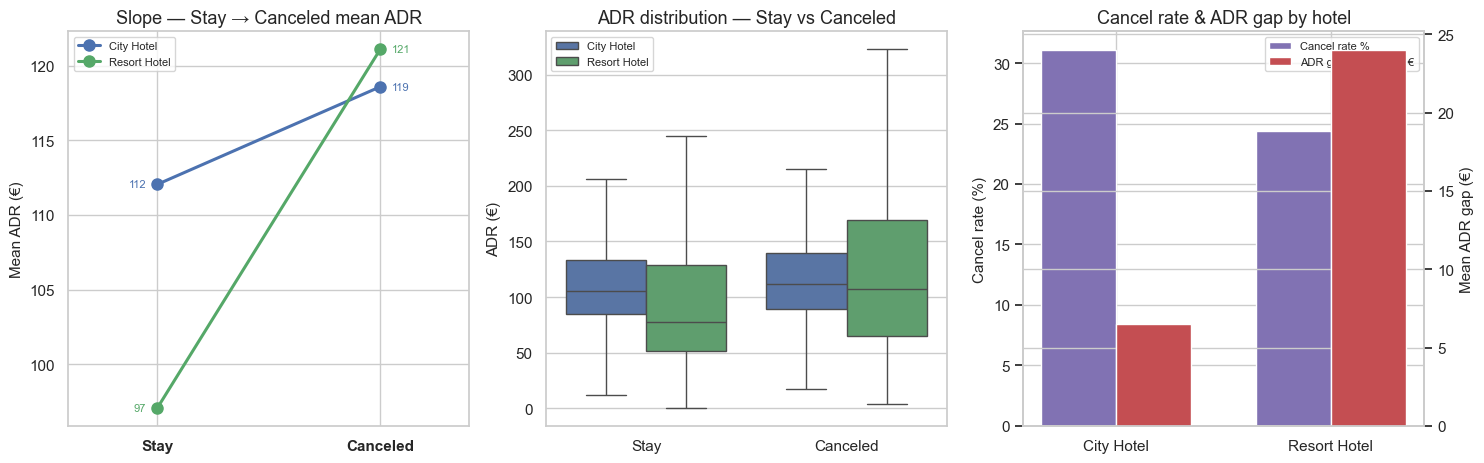

status_label                     Canceled    Stay    gap
hotel        arrival_date_month                         
City Hotel   January                91.00   86.18   4.82
             February               93.69   90.75   2.94
             March                 105.64   93.23  12.41
             April                 124.36  116.96   7.40
             May                   135.98  128.21   7.77
             June                  132.31  124.08   8.23
             July                  122.18  123.46  -1.28
             August                130.98  126.42   4.55
             September             126.20  122.23   3.97
             October               115.36  110.27   5.08
             November               95.79   91.94   3.84
             December               99.05   94.76   4.29
Resort Hotel January                53.86   50.63   3.22
             February               57.12   55.37   1.76
             March                  60.84   59.11   1.73
             April                  88.60   79.83   8.77
             May                    91.19   80.64  10.55
             June                  121.32  111.99   9.33
             July                  169.28  154.07  15.21
             August                199.05  185.26  13.79
             September             111.55  102.09   9.45
             October                71.55   65.38   6.17
             November               49.18   51.18  -2.00
             December               72.70   66.51   6.19

Saved: reports\figures\17b\14b_cancel_gap_by_month.png


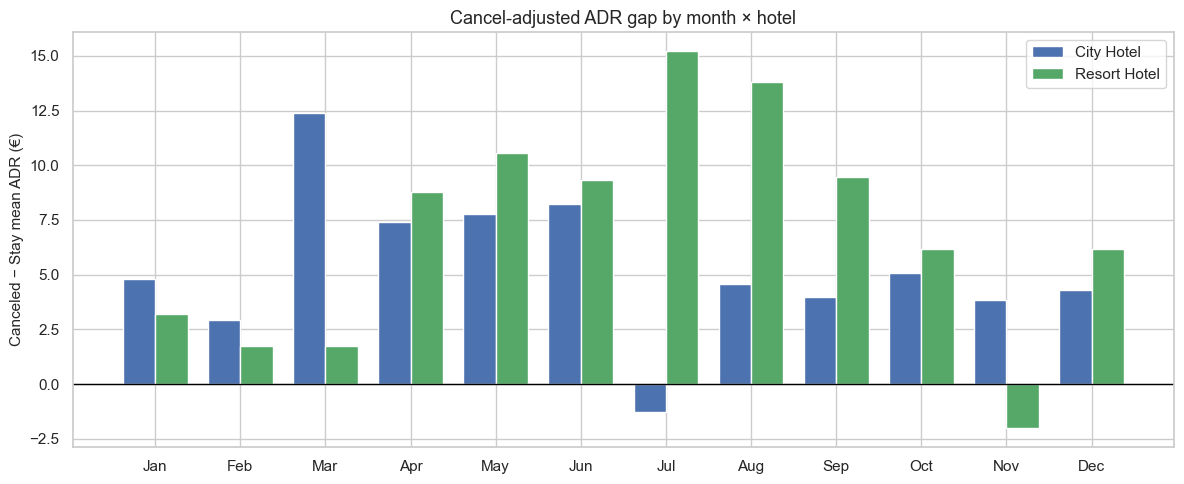

In [18]:
# 4.5 Cancel-adjusted — ADR Stay vs Canceled by hotel
cancel_summary = (
    bookings.groupby(["hotel", "status_label"], observed=True)["adr"]
    .agg(bookings="count", mean_adr="mean", median_adr="median",
         p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75))
    .reset_index()
)
display(cancel_summary.round(2))

# Cancel rate & ADR gap (canceled − stay) per hotel
cancel_kpi = []
for h in HOTELS:
    g = bookings[bookings["hotel"] == h]
    stay_h = g[g["is_canceled"] == 0]["adr"]
    can_h = g[g["is_canceled"] == 1]["adr"]
    u, p = stats.mannwhitneyu(stay_h, can_h, alternative="two-sided")
    cancel_kpi.append({
        "hotel": h,
        "cancel_rate": g["is_canceled"].mean(),
        "mean_stay": stay_h.mean(),
        "mean_canceled": can_h.mean(),
        "gap_canceled_minus_stay": can_h.mean() - stay_h.mean(),
        "median_gap": can_h.median() - stay_h.median(),
        "mannwhitney_p": p,
    })
    print(
        f"{h}: cancel rate {fmt_pct(g['is_canceled'].mean())} | "
        f"mean Stay {fmt_eur(stay_h.mean())} vs Canceled {fmt_eur(can_h.mean())} | "
        f"gap {fmt_eur(can_h.mean() - stay_h.mean())} | MW p={p:.2e}"
    )
cancel_kpi = pd.DataFrame(cancel_kpi).set_index("hotel")
display(cancel_kpi.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

# Slope Stay → Canceled per hotel (mean ADR)
ax = axes[0]
for h in HOTELS:
    row = cancel_kpi.loc[h]
    ax.plot([0, 1], [row["mean_stay"], row["mean_canceled"]],
            color=HOTEL_COLORS[h], lw=2.2, marker="o", markersize=8, label=h)
    ax.text(-0.05, row["mean_stay"], f"{row['mean_stay']:.0f}", ha="right", va="center",
            color=HOTEL_COLORS[h], fontsize=8)
    ax.text(1.05, row["mean_canceled"], f"{row['mean_canceled']:.0f}", ha="left", va="center",
            color=HOTEL_COLORS[h], fontsize=8)
ax.set_xlim(-0.4, 1.4)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Stay", "Canceled"], fontweight="bold")
ax.set_ylabel("Mean ADR (€)")
ax.set_title("Slope — Stay → Canceled mean ADR")
ax.legend(fontsize=8)

ax = axes[1]
sns.boxplot(
    data=bookings, x="status_label", y="adr", hue="hotel",
    order=["Stay", "Canceled"], hue_order=HOTELS, palette=HOTEL_COLORS,
    showfliers=False, ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("ADR (€)")
ax.set_title("ADR distribution — Stay vs Canceled")
ax.legend(title="", fontsize=8)

ax = axes[2]
# Cancel rate + ADR gap grouped
x = np.arange(len(HOTELS))
w = 0.35
bars = ax.bar(x - w / 2, cancel_kpi["cancel_rate"] * 100, width=w,
              color="#8172B3", label="Cancel rate %")
ax2 = ax.twinx()
ax2.bar(x + w / 2, cancel_kpi["gap_canceled_minus_stay"], width=w,
        color="#C44E52", label="ADR gap (Can−Stay) €")
ax.set_xticks(x)
ax.set_xticklabels(HOTELS)
ax.set_ylabel("Cancel rate (%)")
ax2.set_ylabel("Mean ADR gap (€)")
ax.set_title("Cancel rate & ADR gap by hotel")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)

savefig("14_cancel_adjusted_adr.png")
plt.show()

# Optional: month facet — mean ADR stay vs canceled gap by hotel
gap_month = (
    bookings.groupby(["hotel", "arrival_date_month", "status_label"], observed=True)["adr"]
    .mean()
    .unstack("status_label")
    .reindex(MONTH_ORDER, level="arrival_date_month")
)
gap_month["gap"] = gap_month["Canceled"] - gap_month["Stay"]
display(gap_month.round(2))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(12)
w = 0.38
for i, h in enumerate(HOTELS):
    d = gap_month.xs(h, level="hotel")["gap"].reindex(MONTH_ORDER)
    ax.bar(x + (i - 0.5) * w, d.values, width=w, color=HOTEL_COLORS[h], label=h)
ax.axhline(0, color="black", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([m[:3] for m in MONTH_ORDER])
ax.set_ylabel("Canceled − Stay mean ADR (€)")
ax.set_title("Cancel-adjusted ADR gap by month × hotel")
ax.legend()
savefig("14b_cancel_gap_by_month.png")
plt.show()

,hotel,market_segment,n_weekend,n_weekday,weekend_mean,weekday_mean,premium_eur,premium_pct
0,City Hotel,Corporate,294,1410,80.12,83.86,-3.73,-0.04
1,City Hotel,Direct,1838,2573,123.66,123.10,0.56,0.00
2,City Hotel,Groups,521,602,96.13,91.11,5.02,0.06
3,City Hotel,Offline TA/TO,2342,2862,85.58,88.31,-2.73,-0.03
4,City Hotel,Online TA,9502,12129,119.42,118.97,0.45,0.00
5,Resort Hotel,Corporate,192,1245,58.16,50.60,7.56,0.15
6,Resort Hotel,Direct,2322,2738,116.89,112.15,4.74,0.04
7,Resort Hotel,Groups,424,805,68.97,65.02,3.95,0.06
8,Resort Hotel,Offline TA/TO,2467,3040,77.30,74.36,2.94,0.04
9,Resort Hotel,Online TA,4923,5611,109.84,110.08,-0.24,-0.00


Saved: reports\figures\17b\15_small_multiples_weekend_premium_segment.png


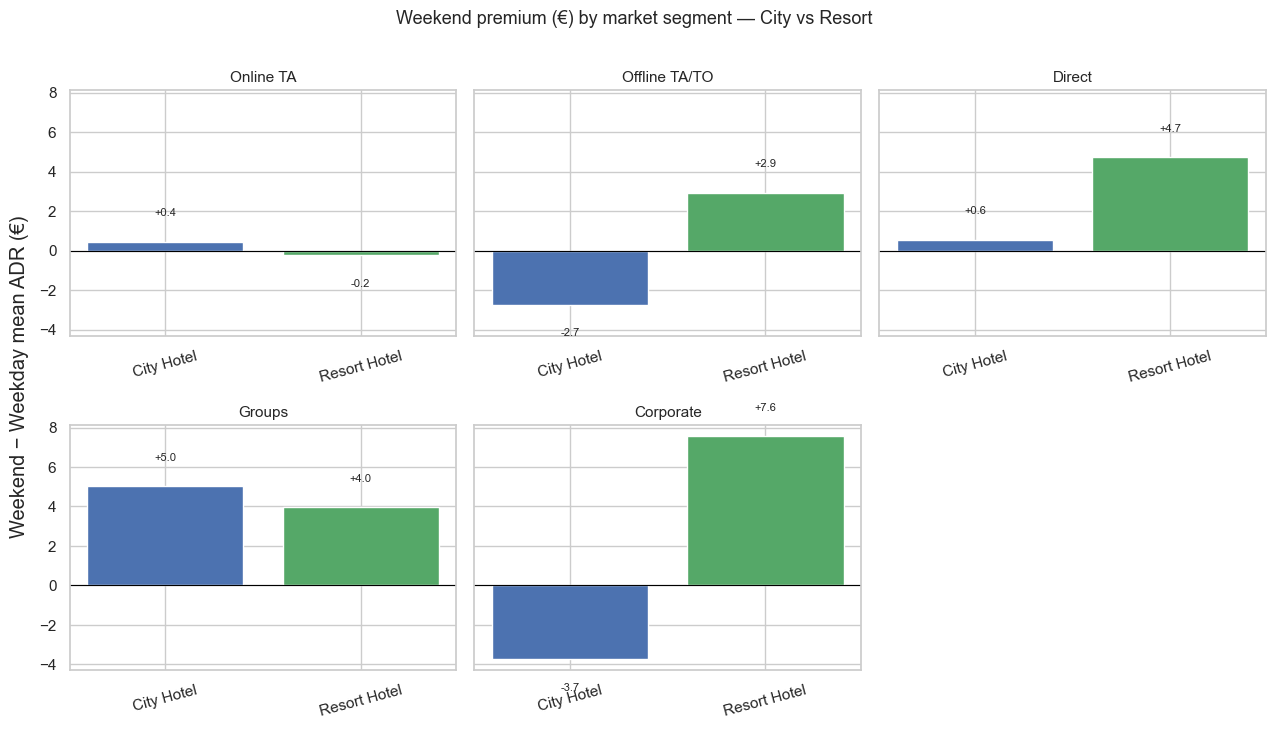

Saved: reports\figures\17b\15b_weekday_weekend_slope_by_segment.png


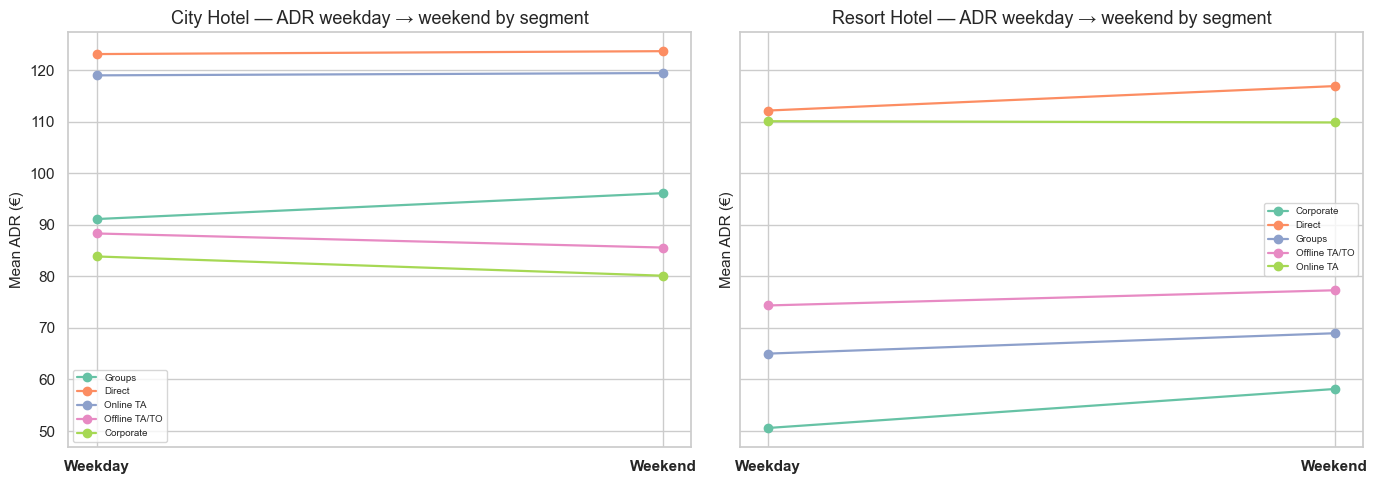

In [19]:
# 4.6 Small multiples — weekend premium by market_segment × hotel
# Top segments by volume (exclude noise)
seg_counts = stay["market_segment"].value_counts()
top_segments = seg_counts[seg_counts >= 200].index.tolist()
# bỏ Complementary / Undefined nếu còn
top_segments = [s for s in top_segments if s not in {"Undefined", "Complementary"}]

prem_rows = []
for h in HOTELS:
    g = stay[(stay["hotel"] == h) & (stay["market_segment"].isin(top_segments))]
    for seg_name, sg in g.groupby("market_segment", observed=True):
        we = sg.loc[sg["is_weekend"], "adr"]
        wd = sg.loc[~sg["is_weekend"], "adr"]
        if len(we) < 30 or len(wd) < 30:
            continue
        prem_rows.append({
            "hotel": h,
            "market_segment": seg_name,
            "n_weekend": len(we),
            "n_weekday": len(wd),
            "weekend_mean": we.mean(),
            "weekday_mean": wd.mean(),
            "premium_eur": we.mean() - wd.mean(),
            "premium_pct": (we.mean() - wd.mean()) / wd.mean() if wd.mean() else np.nan,
        })
prem_seg = pd.DataFrame(prem_rows)
display(prem_seg.round(2))

# Small multiples: one panel per market_segment
segments_plot = (
    prem_seg.groupby("market_segment")["n_weekend"].sum()
    .sort_values(ascending=False)
    .index.tolist()
)
n = len(segments_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.6 * nrows), sharey=True)
axes = np.array(axes).reshape(-1)

for ax, seg_name in zip(axes, segments_plot):
    sub = prem_seg[prem_seg["market_segment"] == seg_name].set_index("hotel")
    vals = [sub.loc[h, "premium_eur"] if h in sub.index else np.nan for h in HOTELS]
    colors = [HOTEL_COLORS[h] for h in HOTELS]
    ax.bar(HOTELS, vals, color=colors)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(seg_name, fontsize=11)
    ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(vals):
        if np.isfinite(v):
            ax.text(i, v + (1.2 if v >= 0 else -1.2), f"{v:+.1f}",
                    ha="center", va="bottom" if v >= 0 else "top", fontsize=8)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Weekend premium (€) by market segment — City vs Resort", y=1.01, fontsize=13)
fig.supylabel("Weekend − Weekday mean ADR (€)")
savefig("15_small_multiples_weekend_premium_segment.png")
plt.show()

# Companion: grouped slope-style lines weekend vs weekday mean ADR per segment×hotel
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, h in zip(axes, HOTELS):
    sub = prem_seg[prem_seg["hotel"] == h].sort_values("premium_eur", ascending=False)
    for _, row in sub.iterrows():
        ax.plot([0, 1], [row["weekday_mean"], row["weekend_mean"]],
                marker="o", lw=1.6, label=row["market_segment"])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Weekday", "Weekend"], fontweight="bold")
    ax.set_title(f"{h} — ADR weekday → weekend by segment")
    ax.set_ylabel("Mean ADR (€)")
    ax.legend(fontsize=7, loc="best")
savefig("15b_weekday_weekend_slope_by_segment.png")
plt.show()

## 5. Executive synthesis — insight theo phân khúc

In [20]:
print("=" * 72)
print("ADR STRATEGY INSIGHTS — CITY vs RESORT")
print("=" * 72)

for h in HOTELS:
    g = subset(h)
    m = g.groupby("arrival_date_month", observed=True)["adr"].mean().reindex(MONTH_ORDER)
    d_mean = premium_tbl.loc[h, "delta_mean"]
    d_pct = premium_tbl.loc[h, "delta_pct"]
    wb = weekend_by_month[weekend_by_month["hotel"] == h]["delta"]
    early = g[g["lead_bin"] == "180+"]["adr"].median()
    late = g[g["lead_bin"] == "0-7"]["adr"].median()
    sp = corr_tbl.loc[h, "spearman"]
    uk = upsell_df.loc[h]

    print(f"\n--- {h} ---")
    print(
        f"1. Seasonality: peak {m.idxmax()} ({fmt_eur(m.max())}) vs low {m.idxmin()} "
        f"({fmt_eur(m.min())}) — spread {fmt_pct(m.max() / m.min() - 1)}."
    )
    print(
        f"2. Weekend premium: {fmt_eur(d_mean)} ({fmt_pct(d_pct)}); "
        f"tháng premium lớn nhất: {wb.idxmax()} ({fmt_eur(wb.max())})."
    )
    print(
        f"3. Lead–ADR: Spearman ρ={sp:.3f}; LM(0-7) med {fmt_eur(late)} vs "
        f"EB(180+) {fmt_eur(early)} (gap {fmt_eur(late - early)})."
    )
    print(
        f"4. Room mis-match {fmt_pct(uk['mismatch_rate'])}; "
        f"free upgrade {fmt_int(uk['free_upgrade_n'])} — opp {fmt_eur(uk['upsell_opp_eur'])}."
    )
    print(f"5. Room ladder: {' < '.join(room_tables[h].index.astype(str))}")

print("\n--- Cross-segment ---")
print(
    f"City mean ADR cao hơn Resort {fmt_eur(gap_mean)} "
    f"(median gap {fmt_eur(gap_med)})."
)
print(
    f"Tháng gap lớn nhất (City−Resort): {gap_m.idxmax()} ({fmt_eur(gap_m.max())}); "
    f"nhỏ nhất / âm nhất: {gap_m.idxmin()} ({fmt_eur(gap_m.min())})."
)

print("\n--- Cancel-adjusted ---")
for h in HOTELS:
    row = cancel_kpi.loc[h]
    print(
        f"{h}: cancel {fmt_pct(row['cancel_rate'])}; "
        f"Canceled−Stay mean ADR {fmt_eur(row['gap_canceled_minus_stay'])}."
    )

print("\n--- Weekend premium by segment (top |Δ|) ---")
top_prem = prem_seg.reindex(prem_seg["premium_eur"].abs().sort_values(ascending=False).index).head(6)
for _, r in top_prem.iterrows():
    print(
        f"{r['hotel']} / {r['market_segment']}: premium {fmt_eur(r['premium_eur'])} "
        f"({fmt_pct(r['premium_pct'])})"
    )

print("\nAction implications (tách property):")
actions = [
    "- City: bảo vệ midweek BAR (công vụ); weekend surcharge chọn tháng có premium dương.",
    "- Resort: rate calendar theo peak hè mạnh hơn; weekend / holiday premium ưu tiên hơn City.",
    "- Lead window: so sánh LM−EB gap — property có gap lớn hơn cần floor early-bird riêng.",
    "- Upsell: chạy paid upgrade theo ladder từng hotel (không dùng chung alphabet/rank).",
    "- Cancel-adjusted: nếu canceled ADR lệch Stay → review discount / OTA dump trên booking dễ hủy.",
    "- Segment weekend premium: surcharge / package theo market_segment × hotel (small multiples).",
    "- Forecast / dynamic pricing (nb 18): model và stance nên tách City vs Resort.",
]
for a in actions:
    print(a)

ADR STRATEGY INSIGHTS — CITY vs RESORT

--- City Hotel ---
1. Seasonality: peak May (128,21 €) vs low January (86,18 €) — spread 48,8%.
2. Weekend premium: 1,24 € (1,1%); tháng premium lớn nhất: May (5,43 €).
3. Lead–ADR: Spearman ρ=-0.001; LM(0-7) med 102,80 € vs EB(180+) 99,45 € (gap 3,35 €).
4. Room mis-match 13,8%; free upgrade 3.399 — opp 348.140,41 €.
5. Room ladder: B < A < K < C < D < E < F < G

--- Resort Hotel ---
1. Seasonality: peak August (185,26 €) vs low January (50,63 €) — spread 265,9%.
2. Weekend premium: 6,81 € (7,2%); tháng premium lớn nhất: September (10,81 €).
3. Lead–ADR: Spearman ρ=0.191; LM(0-7) med 63,00 € vs EB(180+) 84,58 € (gap -21,58 €).
4. Room mis-match 23,9%; free upgrade 5.112 — opp 681.861,25 €.
5. Room ladder: A < I < D < E < B < F < L < G < C < H

--- Cross-segment ---
City mean ADR cao hơn Resort 14,96 € (median gap 27,50 €).
Tháng gap lớn nhất (City−Resort): May (47,58 €); nhỏ nhất / âm nhất: August (-58,84 €).

--- Cancel-adjusted ---
City Hotel: